# Notebook 1 — Data Loading & Exploration

This notebook demonstrates how to download and explore the **Waymo Open Dataset v2** (parquet format).

**Before running:** ensure you have:
1. Accepted the Waymo ToS at https://waymo.com/open/licensing/
2. Authenticated: `gcloud auth login`
3. Downloaded data: `python src/data/download.py --split validation --num_segments 5`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.waymo_loader import load_dataset, extract_trajectories

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## Load dataset

In [2]:
DATA_DIR = '../data'

dataset = load_dataset(DATA_DIR, max_segments=5)
print('Components loaded:', list(dataset.keys()))

if 'lidar_box' in dataset:
    lb = dataset['lidar_box']
    print(f'lidar_box shape: {lb.shape}')
    print(f'Segments: {lb["segment_id"].nunique()}')
    print(f'Frames per segment (approx): {lb["timestamp_us"].nunique() / lb["segment_id"].nunique():.0f}')
    lb.head()

Components loaded: ['lidar_box', 'vehicle_pose']
lidar_box shape: (62953, 17)
Segments: 5
Frames per segment (approx): 198


## Agent type distribution

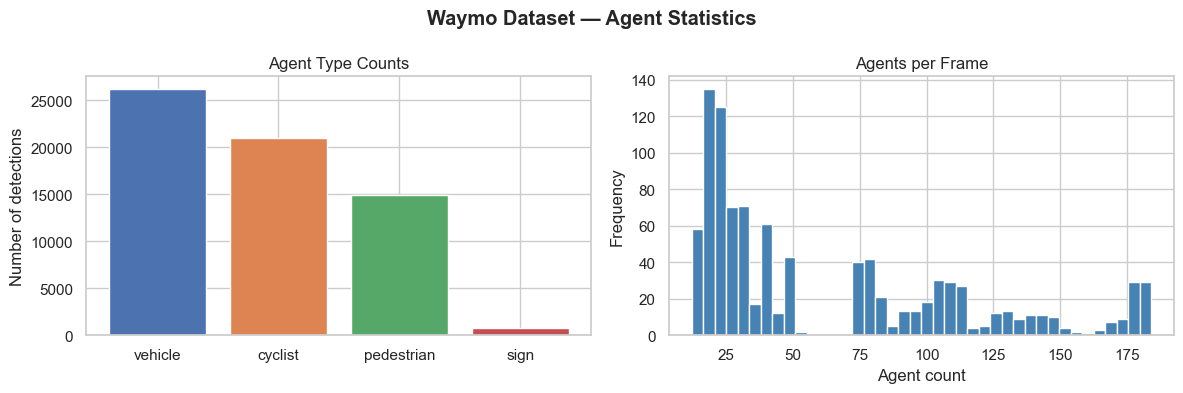

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = lb['object_type_name'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=sns.color_palette('deep', len(type_counts)))
axes[0].set_title('Agent Type Counts')
axes[0].set_ylabel('Number of detections')

agents_per_frame = lb.groupby(['segment_id', 'timestamp_us'])['object_id'].count()
axes[1].hist(agents_per_frame, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Agents per Frame')
axes[1].set_xlabel('Agent count')
axes[1].set_ylabel('Frequency')

plt.suptitle('Waymo Dataset — Agent Statistics', fontweight='bold')
plt.tight_layout()
plt.show()

## Extract trajectories and kinematic features

In [4]:
trajectories = extract_trajectories(lb)
print(f'Trajectory rows: {len(trajectories):,}')
print(f'Unique objects: {trajectories["object_id"].nunique():,}')
trajectories[['segment_id', 'object_id', 'timestamp_s', 'x', 'y',
              'speed', 'acceleration', 'jerk', 'heading_rate']].head(10)

Trajectory rows: 62,312
Unique objects: 638


,segment_id,object_id,timestamp_s,x,y,speed,acceleration,jerk,heading_rate
0,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,72.363684,-19.887612,0.010189,2.309007e-13,NaN,0.031469
1,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,70.674284,-19.657254,0.010189,6.438702e-12,6.206742e-11,0.032299
2,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,69.004706,-19.405936,0.010189,1.704892e-09,1.697961e-08,0.036416
3,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,67.356758,-19.122352,0.010189,1.703215e-09,-1.676038e-11,0.042046
4,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,65.721728,-18.832931,0.010189,8.576225e-10,-8.448238e-09,0.044079
5,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,64.091977,-18.568949,0.010189,1.055305e-11,-8.462733e-09,0.040570
6,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,62.480730,-18.281891,0.010189,8.559651e-10,8.448710e-09,0.045160
7,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,60.872522,-18.013142,0.010189,1.680029e-09,8.232399e-09,0.043721
8,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,59.272654,-17.762479,0.010189,1.683103e-09,3.071229e-11,0.041739
9,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,1.522688e+09,57.679939,-17.531516,0.010189,8.608480e-10,-8.214742e-09,0.039004


## Speed distribution by object type

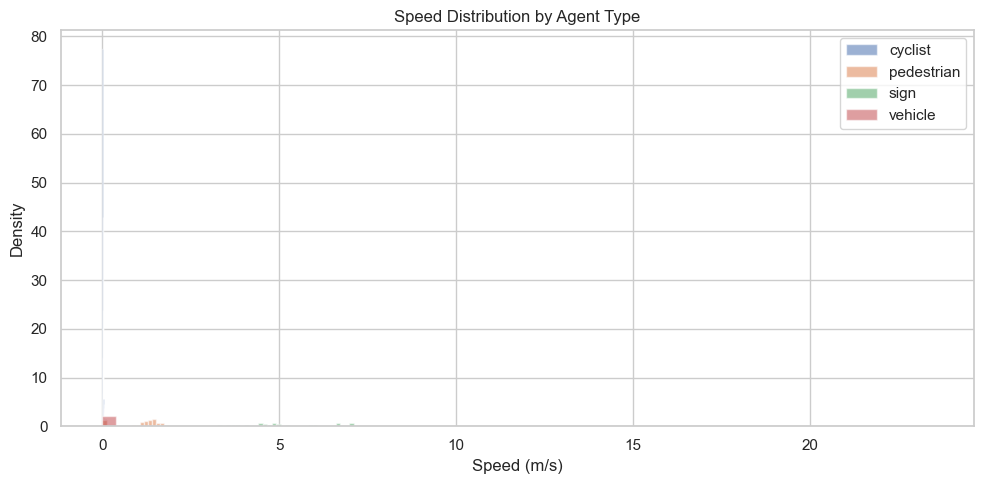

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for obj_type, group in trajectories.groupby('object_type_name'):
    speeds = group['speed'].clip(0, 30)
    ax.hist(speeds, bins=60, alpha=0.55, label=obj_type, density=True)
ax.set_xlabel('Speed (m/s)')
ax.set_ylabel('Density')
ax.set_title('Speed Distribution by Agent Type')
ax.legend()
plt.tight_layout()
plt.show()

## Kinematic feature summary statistics

In [6]:
features = ['speed', 'acceleration', 'jerk', 'heading_rate']
trajectories[features].describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
speed,62312.000000,1.165780,3.399473,0.000000,0.000825,0.013311,1.114737,23.469262
acceleration,62312.000000,0.107354,0.312886,0.000000,0.000000,0.000000,0.052554,4.185801
jerk,61674.000000,0.000033,0.329787,-24.010642,-0.000000,0.000000,0.000000,7.128364
heading_rate,62312.000000,-0.002882,2.921458,-62.858789,-0.010842,-0.000072,0.003885,62.859260
